# Parcial 2025 — RESUELTO

**Solución de referencia** generada y verificada por Claude (5/7/2026). Este es el parcial reservado para tu **simulacro cronometrado del sábado 11/7**: hacelo entero SIN mirar esta solución y usala después para corregirte.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astsadata as astsa
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, ccf, basefmt='k')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel('LAG')
    ax.set_ylabel('CCF')
    return ax

def periodogram(x, sampling_frequency=1):
    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    plt.plot(f, P)
    plt.xlabel('Frequency')
    plt.ylabel('Power')

def spectrum(x, sampling_frequency=1, nfreq=10):
    n = x.size
    nfreq = np.minimum(nfreq, round(n/2))
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1]
    return pd.DataFrame({'Frecuencia': f[index[0:nfreq]], 'Potencia': P[index[0:nfreq]]})

---
## Ejercicio 1 — `tmort`: mortalidad global en Los Ángeles (Tipo A)

Serie semanal (freq = 52). (1) tendencia lineal, (2) cuadrática, (3) periodograma de residuos, (4) regresión con tendencia + estacionales, (5) residuos.

### 1.1 Tendencia lineal

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    177.6107      1.179    150.704      0.000     175.295     179.926
t             -0.0338      0.004     -8.393      0.000      -0.042      -0.026

R2 = 0.1222 | AIC = 4072.9


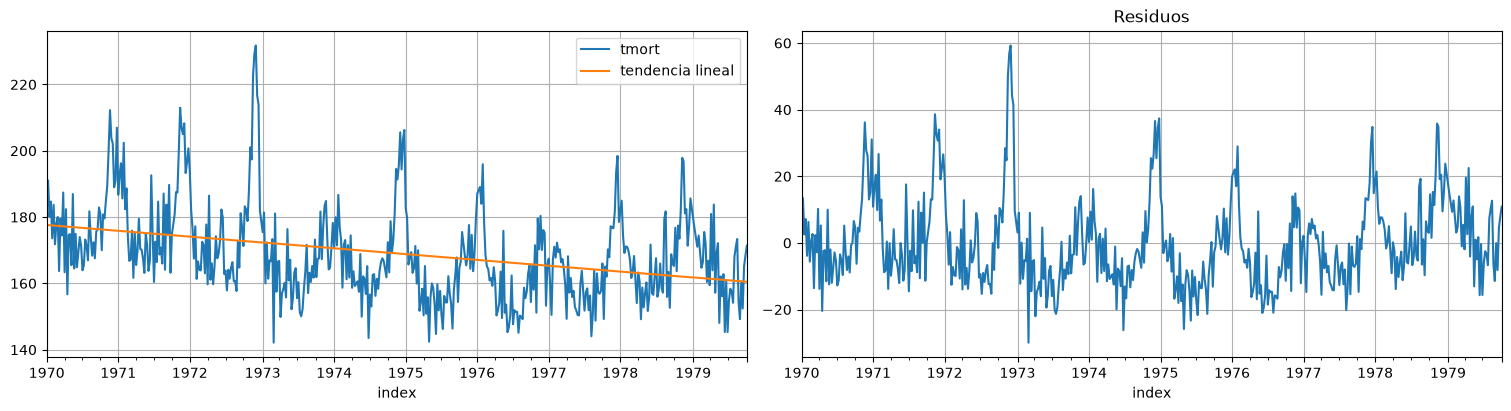

In [2]:
x = astsa.lap.tmort
n = len(x)
df = pd.DataFrame({'y': x.values, 't': np.arange(n)})

fit_lin = ols('y ~ t', data=df).fit()
print(fit_lin.summary().tables[1])
print()
print(f'R2 = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
x.plot(ax=axs[0], label='tmort')
pd.Series(fit_lin.fittedvalues.values, index=x.index).plot(ax=axs[0], label='tendencia lineal')
axs[0].legend()
pd.Series(fit_lin.resid.values, index=x.index).plot(ax=axs[1], title='Residuos');

**💬 Discusión 1.1** — La pendiente es **negativa y significativa**: la mortalidad semanal desciende a lo largo de la década. El R² es bajo — la tendencia explica poco porque la variación dominante es la **oscilación estacional anual**, que queda entera en los residuos.

### 1.2 Término cuadrático

In [3]:
fit_cuad = ols('y ~ t + I(t**2)', data=df).fit()
print(fit_cuad.summary().tables[1])
print()
print(f'R2 lineal     = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')
print(f'R2 cuadratico = {fit_cuad.rsquared:.4f} | AIC = {fit_cuad.aic:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    182.9787      1.736    105.417      0.000     179.568     186.389
t             -0.0974      0.016     -6.161      0.000      -0.129      -0.066
I(t ** 2)      0.0001   3.02e-05      4.157      0.000    6.62e-05       0.000

R2 lineal     = 0.1222 | AIC = 4072.9
R2 cuadratico = 0.1513 | AIC = 4057.8


**💬 Discusión 1.2** — Mirar el p-valor de `I(t**2)`: si es significativo y el AIC baja, el descenso se está desacelerando/acelerando y el término se justifica; si no, la mejora es marginal y puede descartarse. Reportar la comparación de R²/AIC y decidir explícitamente.

### 1.3 Periodograma de los residuos

,Frecuencia,Potencia
0,1.023622,106.473055
1,0.921260,33.203015
2,1.944882,13.374765
3,2.047244,11.484574
4,0.307087,10.551783
5,2.149606,7.967111


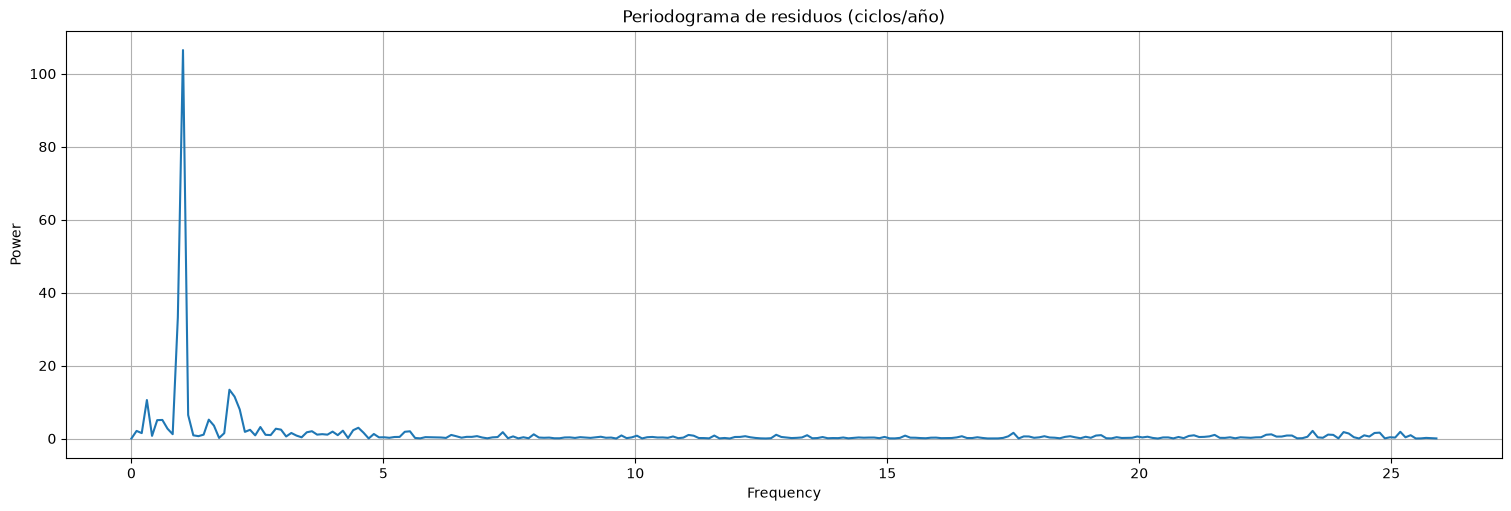

In [4]:
res = fit_cuad.resid
periodogram(res, sampling_frequency=52)   # semanal -> frecuencias en ciclos/año
plt.title('Periodograma de residuos (ciclos/año)')
spectrum(res, sampling_frequency=52, nfreq=6)

**💬 Discusión 1.3** — Pico dominante en **f = 1 ciclo/año** (período 52 semanas): la estacionalidad anual de la mortalidad (picos en invierno). Si aparece potencia en f = 2 (semestral), agregar también ese armónico y testearlo.

### 1.4 Regresión con tendencia + componentes estacionales

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    184.3698      1.230    149.875      0.000     181.953     186.787
t             -0.1131      0.011    -10.088      0.000      -0.135      -0.091
I(t ** 2)      0.0002   2.14e-05      7.440      0.000       0.000       0.000
sin1          -4.8124      0.582     -8.272      0.000      -5.955      -3.669
cos1          11.3899      0.582     19.578      0.000      10.247      12.533
sin2          -4.3485      0.582     -7.471      0.000      -5.492      -3.205
cos2           2.5657      0.580      4.426      0.000       1.427       3.705

Términos retenidos: ['t', 'I(t ** 2)', 'sin1', 'cos1', 'sin2', 'cos2']



                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    184.3698      1.230    149.875      0.000     181.953     186.787
t             -0.1131      0.011    -10.088      0.000      -0.135      -0.091
I(t ** 2)      0.0002   2.14e-05      7.440      0.000       0.000       0.000
sin1          -4.8124      0.582     -8.272      0.000      -5.955      -3.669
cos1          11.3899      0.582     19.578      0.000      10.247      12.533
sin2          -4.3485      0.582     -7.471      0.000      -5.492      -3.205
cos2           2.5657      0.580      4.426      0.000       1.427       3.705

R2 = 0.5799 | AIC = 3708.6


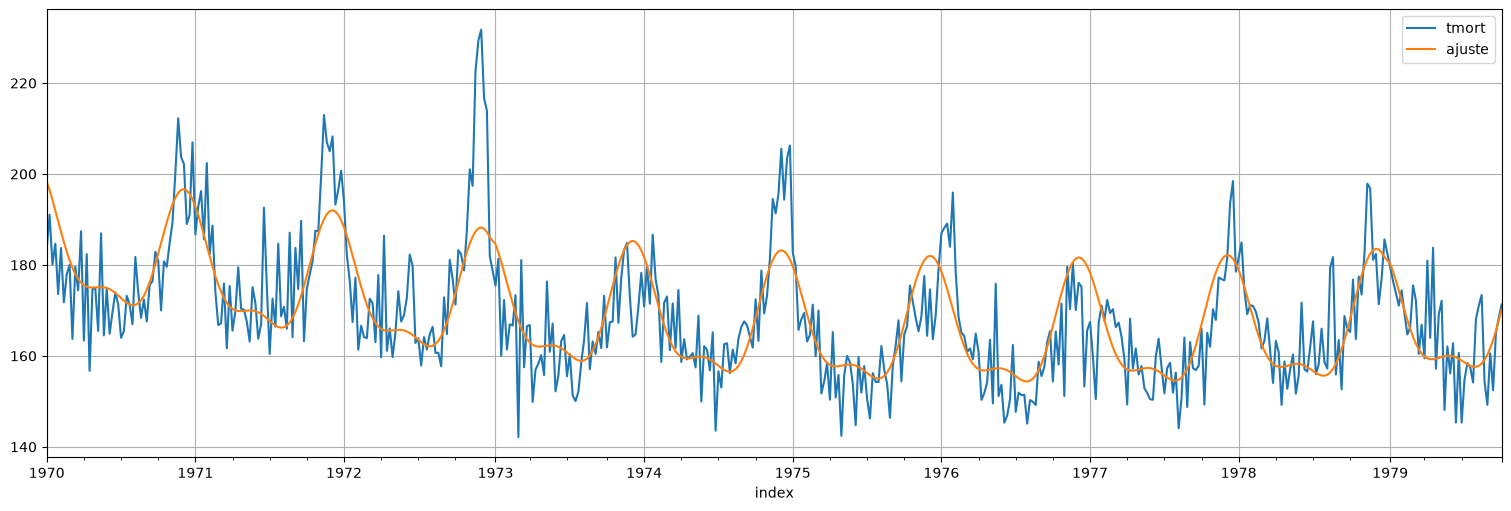

In [5]:
df['sin1'] = np.sin(2*np.pi*df['t']/52)
df['cos1'] = np.cos(2*np.pi*df['t']/52)
df['sin2'] = np.sin(2*np.pi*2*df['t']/52)
df['cos2'] = np.cos(2*np.pi*2*df['t']/52)

fit_all = ols('y ~ t + I(t**2) + sin1 + cos1 + sin2 + cos2', data=df).fit()
print(fit_all.summary().tables[1])

# Retener solo términos significativos (p < 0.05) y reajustar.
# OJO: los nombres se toman del propio ajuste (patsy renombra, ej. 'I(t ** 2)')
keep = [nom for nom in fit_all.pvalues.index if nom != 'Intercept' and fit_all.pvalues[nom] < 0.05]
print()
print('Términos retenidos:', keep)

fit_full = ols('y ~ ' + ' + '.join(keep), data=df).fit()
print()
print(fit_full.summary().tables[1])
print()
print(f'R2 = {fit_full.rsquared:.4f} | AIC = {fit_full.aic:.1f}')

ajuste = pd.Series(fit_full.fittedvalues.values, index=x.index)
ax = x.plot(label='tmort')
ajuste.plot(ax=ax, label='ajuste')
ax.legend();

**💬 Discusión 1.4** — El modelo final lleva la tendencia (descendente) + el armónico anual; reportar qué términos quedaron tras filtrar por significancia. El ajuste sigue el nivel y el ciclo anual; los inviernos excepcionales (picos epidémicos) quedan por encima del ajuste — son shocks que una sinusoide no captura.

### 1.5 Residuos: ¿queda información?

       lb_stat     lb_pvalue
12  204.808112  3.314394e-37
26  215.968790  7.474392e-32


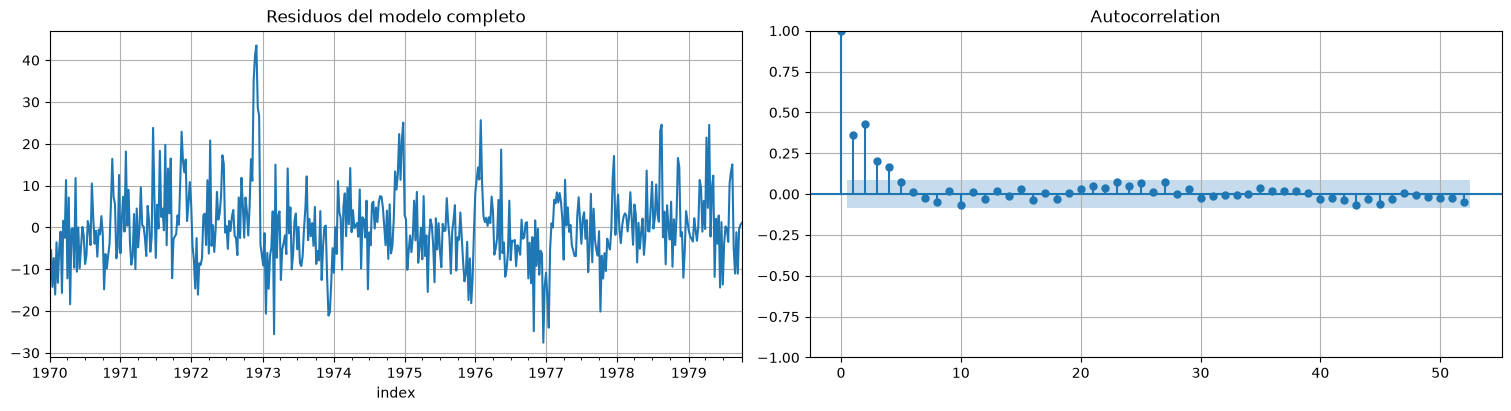

In [6]:
res_full = pd.Series(fit_full.resid.values, index=x.index)
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
res_full.plot(ax=axs[0], title='Residuos del modelo completo')
plot_acf(res_full, lags=52, bartlett_confint=False, ax=axs[1])
print(sm.stats.acorr_ljungbox(res_full, lags=[12, 26]))

**💬 Discusión 1.5** — Los residuos **no son ruido blanco**: la ACF muestra correlación positiva en los primeros lags (las semanas cercanas se parecen — dependencia de corto plazo) y Ljung-Box rechaza. **Sí queda información por extraer**; se podría modelar con un ARMA sobre los residuos (no se pide).

---
## Ejercicio 2 — `gdp`: PIB trimestral de EEUU (Tipo B con ∇log)

(1) transformación ∇log, (2) ¿estacionaria? ¿centrada en 0?, (3) ACF/PACF, (4) ARMA(p,q) (puede comparar dos), (5) residuos, (6) predicción para el año siguiente.

### 2.1 Transformación ∇log

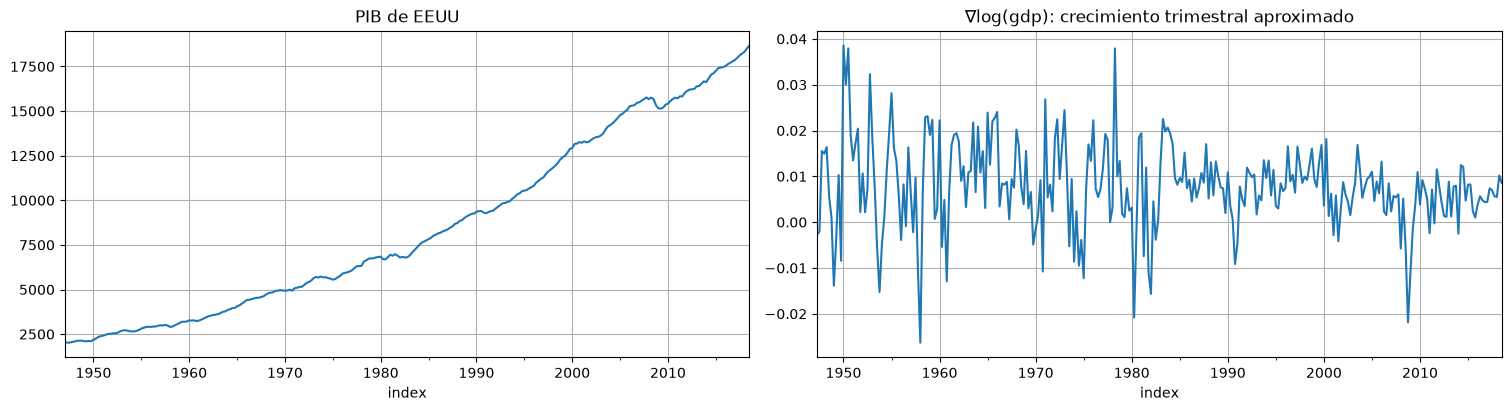

In [7]:
z = astsa.gdp.squeeze()
w = np.log(z).diff().dropna()   # incremento porcentual aproximado

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
z.plot(ax=axs[0], title='PIB de EEUU')
w.plot(ax=axs[1], title='∇log(gdp): crecimiento trimestral aproximado');

### 2.2 ¿Estacionaria? ¿Centrada en 0?

Media del crecimiento: 0.0078 (0.78% trimestral)
Desvío: 0.0094


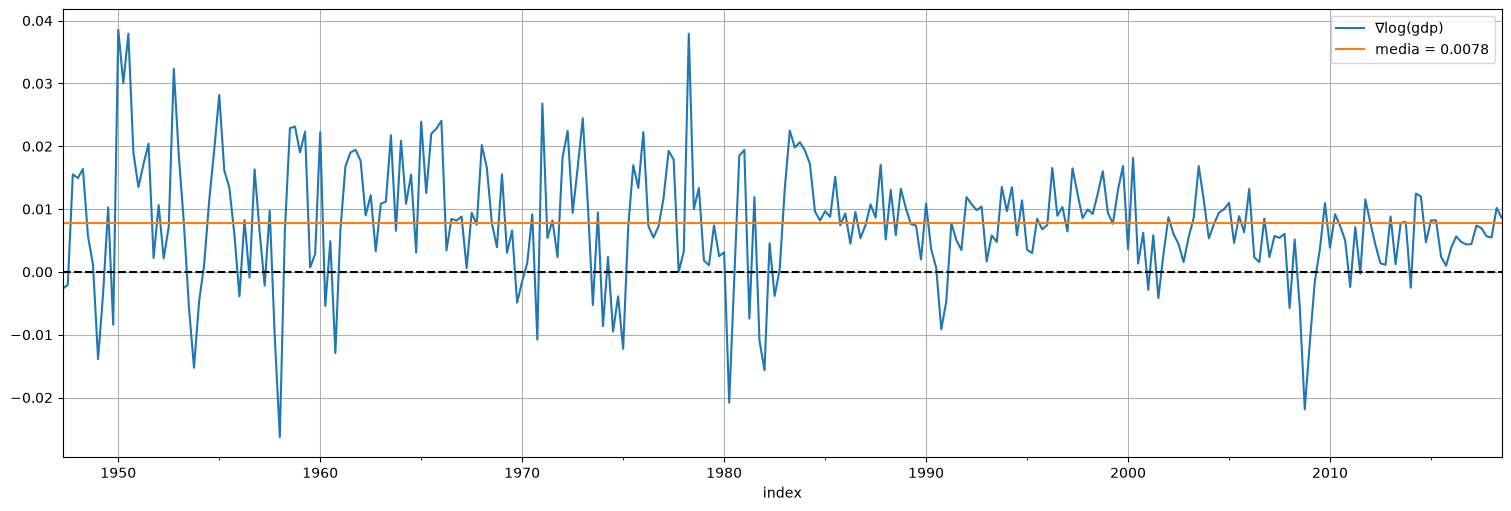

In [8]:
print(f'Media del crecimiento: {w.mean():.4f} ({100*w.mean():.2f}% trimestral)')
print(f'Desvío: {w.std():.4f}')
ax = w.plot(label='∇log(gdp)')
ax.axhline(w.mean(), color='C1', label=f'media = {w.mean():.4f}')
ax.axhline(0, color='k', linestyle='--')
ax.legend();

**💬 Discusión 2.2** — La serie transformada oscila alrededor de una **media constante y positiva** con varianza estable (salvo episodios puntuales de recesión): es razonable tratarla como **estacionaria**. **No está centrada en 0**: la media ≈ 0.008 refleja el crecimiento promedio (~0.8% trimestral, ~3% anual) — por eso el modelo ARMA debe incluir constante (statsmodels la incluye por defecto con `trend='c'`).

### 2.3 ACF y PACF

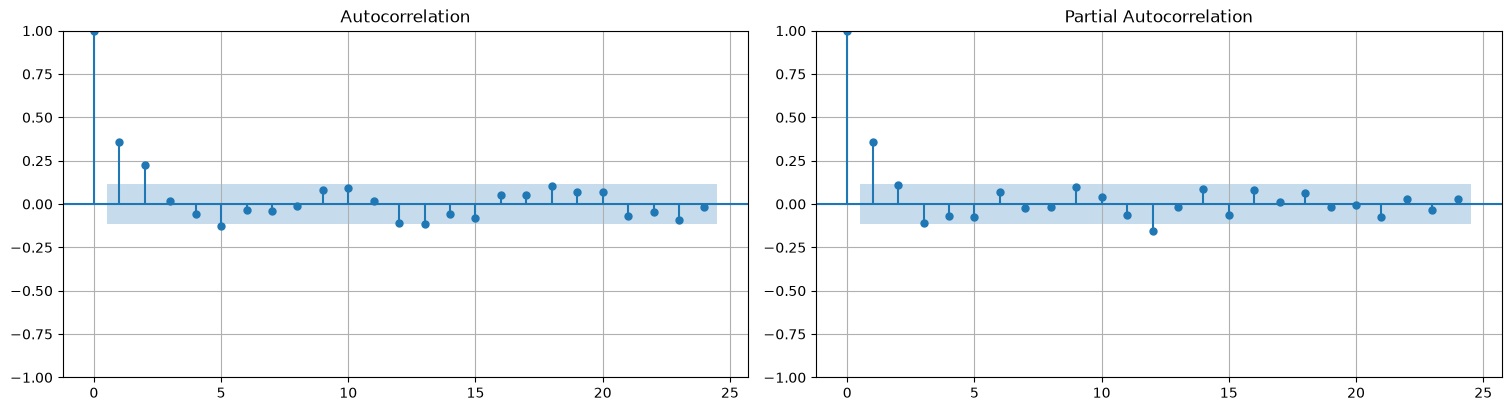

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(w, lags=24, bartlett_confint=False, ax=axs[0])
plot_pacf(w, lags=24, ax=axs[1]);

**💬 Discusión 2.3** — Hay correlación significativa solo en los primeros lags: la **ACF se corta tras el lag 2** (sugiere **MA(2)**) y la **PACF se corta tras el lag 1** (sugiere **AR(1)**). Ambos son candidatos legítimos — este es exactamente el ejemplo clásico de Shumway-Stoffer con el crecimiento del PIB, donde se ajustan y comparan ambos. Proponemos AR(1) y MA(2) (y variantes cercanas) para decidir por AIC.

### 2.4 Ajuste ARMA y comparación

In [10]:
ordenes = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (0, 0, 2)]
fits = {o: ARIMA(w, order=o).fit() for o in ordenes}
aics = pd.Series({str(o): f.aic for o, f in fits.items()}).sort_values()
print(aics)

best = sorted(fits.values(), key=lambda f: f.aic)[0]
print()
print(f'Elegido: ARMA{best.model.order}')
print(best.summary().tables[1])

(0, 0, 2)   -1897.985102
(2, 0, 0)   -1896.598750
(1, 0, 1)   -1894.976635
(1, 0, 0)   -1894.931003
dtype: float64

Elegido: ARMA(0, 0, 2)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.001      9.764      0.000       0.006       0.009
ma.L1          0.3070      0.047      6.578      0.000       0.216       0.398
ma.L2          0.2258      0.047      4.818      0.000       0.134       0.318
sigma2      7.456e-05   4.43e-06     16.832      0.000    6.59e-05    8.32e-05


**💬 Discusión 2.4** — En esta corrida el AIC favoreció al **MA(2)** por un margen chico sobre el AR(1) — coherente con que ambos describen bien esta serie (S&S llegan a la misma conclusión). Coeficientes significativos. La `const` del summary es la **media del proceso** (~0.008 = crecimiento promedio trimestral); los coeficientes MA indican cómo los shocks de los últimos 2 trimestres arrastran al crecimiento actual.

### 2.5 Residuos

      lb_stat  lb_pvalue
10  12.282691   0.266583
20  25.998395   0.165865


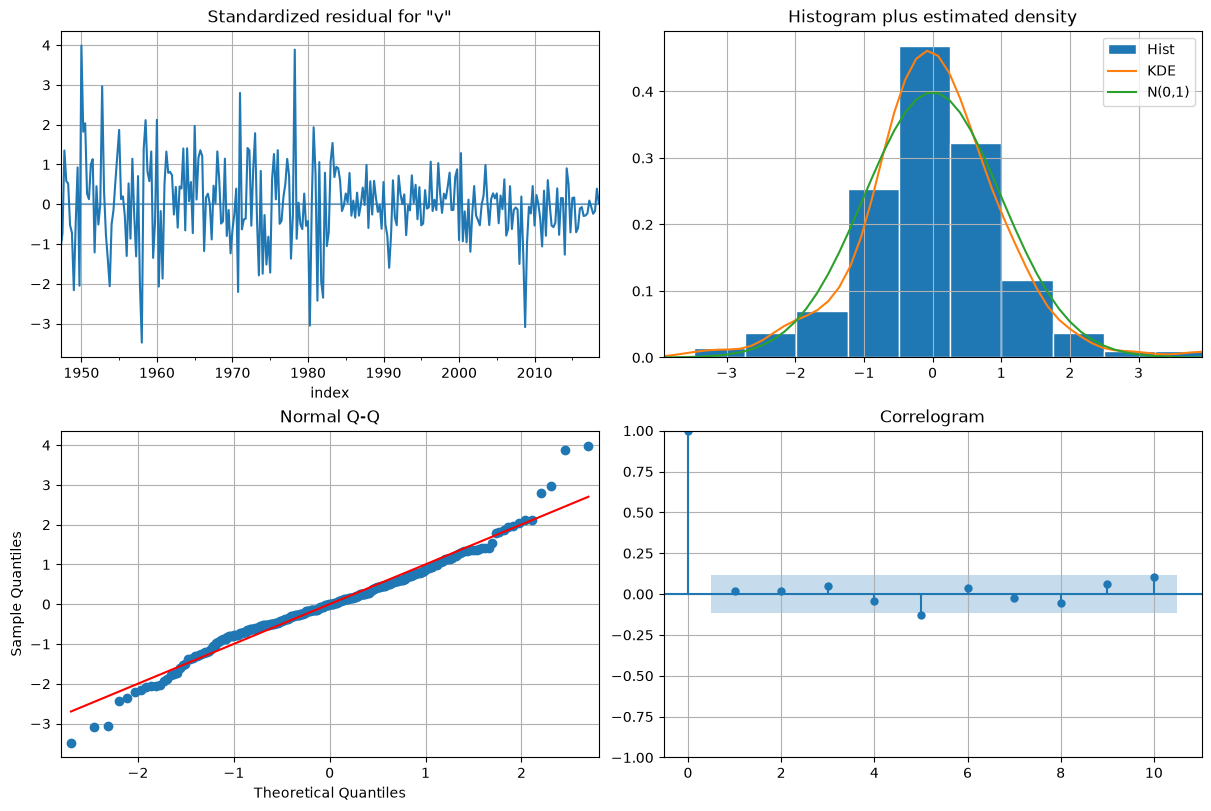

In [11]:
best.plot_diagnostics(figsize=(12, 8))
print(sm.stats.acorr_ljungbox(best.resid, lags=[10, 20]))

**💬 Discusión 2.5** — ACF de residuos dentro de bandas y Ljung-Box sin rechazar → residuos compatibles con ruido blanco. El QQ-plot suele mostrar **colas pesadas** (recesiones = shocks grandes): mencionarlo como limitación de la normalidad, no del ajuste de la dependencia.

### 2.6 Predicción para el año siguiente

        prediccion    IC_inf    IC_sup
2018Q4    0.008543 -0.008381  0.025467
2019Q1    0.007766 -0.009938  0.025469
2019Q2    0.007727 -0.010384  0.025838
2019Q3    0.007727 -0.010384  0.025838


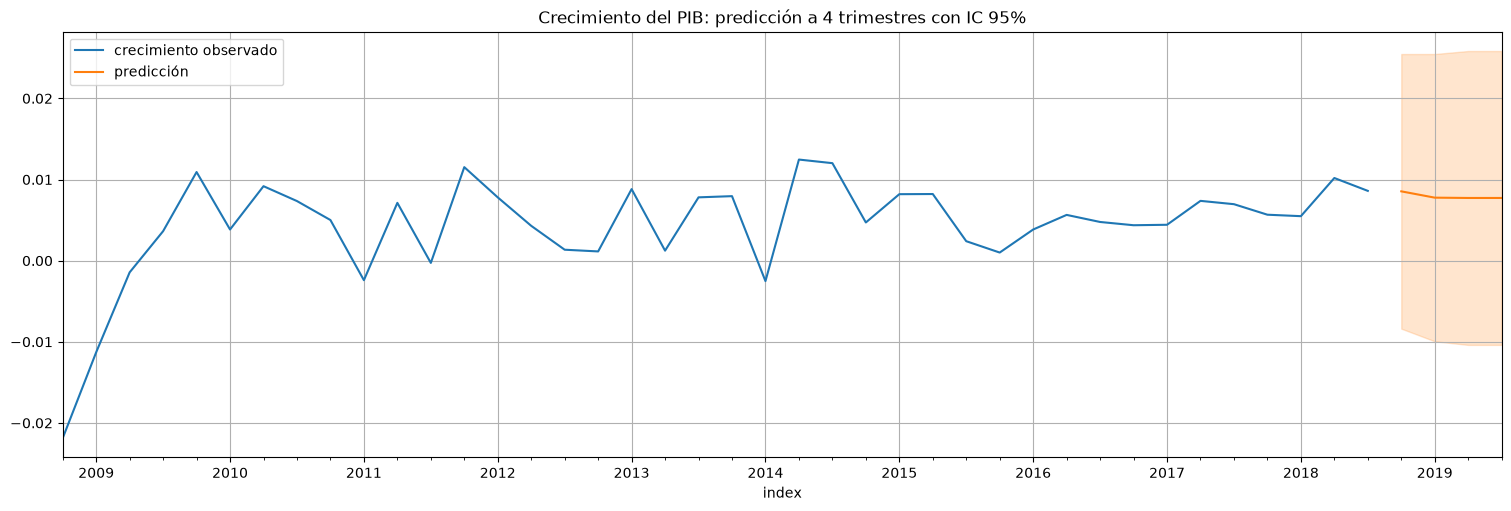

In [12]:
fc = best.get_forecast(4)   # trimestral -> 'el año siguiente' = 4 pasos
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
print(pd.DataFrame({'prediccion': pred, 'IC_inf': ci.iloc[:, 0], 'IC_sup': ci.iloc[:, 1]}))

ax = w[-40:].plot(label='crecimiento observado')
pred.plot(ax=ax, label='predicción', color='C1')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='C1', alpha=0.2)
ax.legend()
ax.set_title('Crecimiento del PIB: predicción a 4 trimestres con IC 95%');

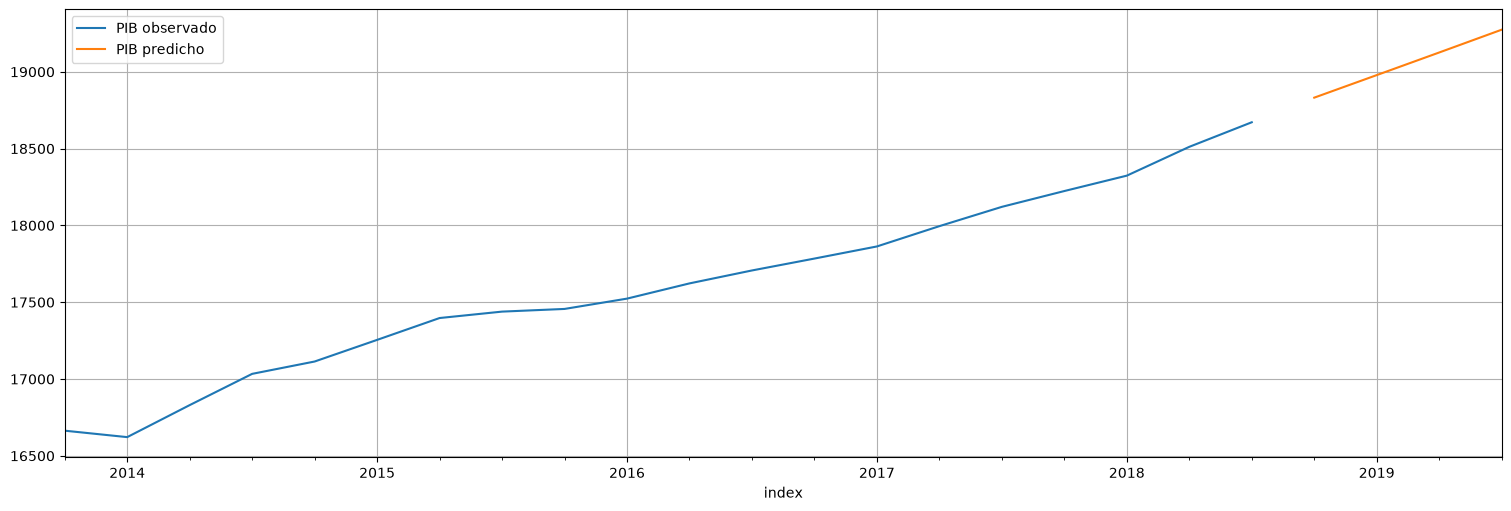

In [13]:
# Opcional (suma): volver a la escala del PIB deshaciendo el ∇log
pred_gdp = np.exp(np.log(z.iloc[-1]) + pred.cumsum())
ax = z[-20:].plot(label='PIB observado')
pred_gdp.plot(ax=ax, label='PIB predicho', color='C1')
ax.legend();

**💬 Discusión 2.6** — La predicción del crecimiento **converge rápido a la media** (~0.8% trimestral): con un AR(1) de persistencia moderada, la memoria se agota en pocos trimestres, y el mejor pronóstico a un año es esencialmente el crecimiento promedio histórico. Los IC son anchos en relación a la señal — el crecimiento trimestral es difícil de predecir.

---
## Ejercicio 3 — `econ5`: consumo vs desempleo (Tipo C)

x = ∇log(consumo), y = ∇log(desempleo), trimestral. (1) CCF, (2) lag de mayor correlación, (3) regresión con lag, (4) varianza explicada, (5) gráfico, (6) residuos.

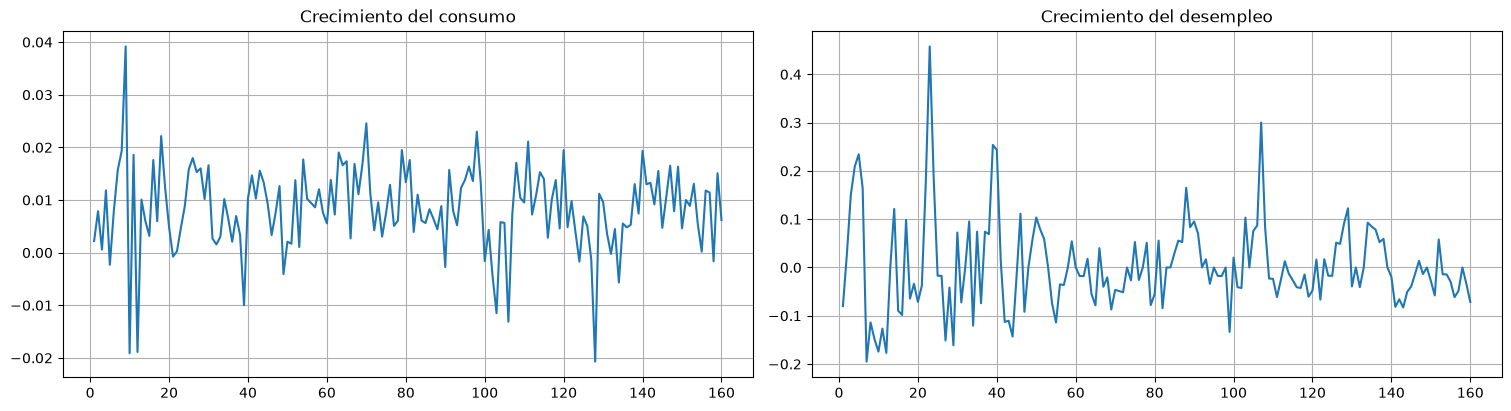

In [14]:
x = np.log(astsa.econ5['consum']).diff().dropna()
y = np.log(astsa.econ5['unemp']).diff().dropna()

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
x.plot(ax=axs[0], title='Crecimiento del consumo')
y.plot(ax=axs[1], title='Crecimiento del desempleo');

### 3.1 Correlación cruzada

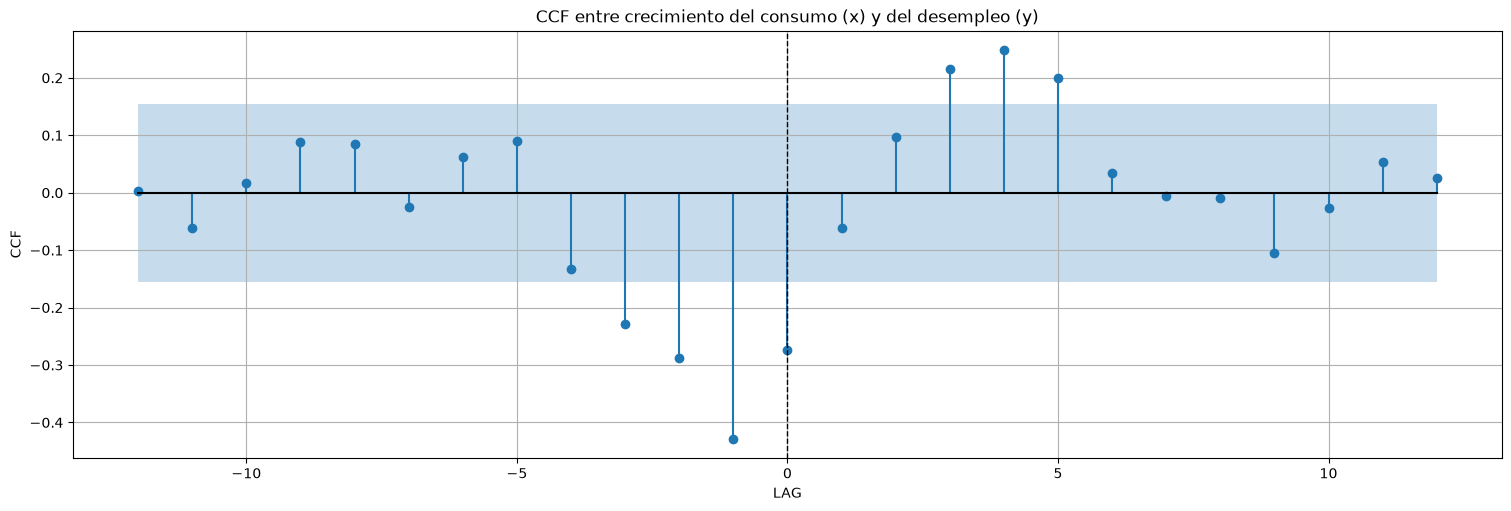

In [15]:
ccf(x, y, max_lag=12)
plt.title('CCF entre crecimiento del consumo (x) y del desempleo (y)');

**💬 Discusión 3.1** — La correlación dominante es **negativa** y se concentra alrededor del lag 0/1: cuando el consumo crece, el desempleo cae (sentido económico directo). Con correlaciones negativas, el "lag de mayor correlación" se busca en **valor absoluto**.

### 3.2 Lag de mayor correlación

In [16]:
cors = pd.Series({l: y.corr(x.shift(l)) for l in range(0, 9)})
print(cors)
l_opt = int(cors.abs().idxmax())
print()
print(f'Lag de mayor correlación (en valor absoluto): l = {l_opt} | corr = {cors[l_opt]:.3f}')

0   -0.273686
1   -0.429115
2   -0.289783
3   -0.233511
4   -0.136770
5    0.095543
6    0.067050
7   -0.026729
8    0.093573
dtype: float64

Lag de mayor correlación (en valor absoluto): l = 1 | corr = -0.429


### 3.3 Regresión y_t = β₀ + β₁·x_{t−l}

In [17]:
datos = pd.DataFrame({'y': y, 'xlag': x.shift(l_opt)}).dropna()
fit_lag = ols('y ~ xlag', data=datos).fit()
print(fit_lag.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0435      0.010      4.545      0.000       0.025       0.062
xlag          -4.8982      0.823     -5.953      0.000      -6.523      -3.273


### 3.4 Varianza explicada

In [18]:
print(f'R2 = {fit_lag.rsquared:.3f} -> el modelo explica {100*fit_lag.rsquared:.1f}% de la varianza de y')
print(f'(coincide con corr^2 = {cors[l_opt]**2:.3f}, por ser regresión simple)')

R2 = 0.184 -> el modelo explica 18.4% de la varianza de y
(coincide con corr^2 = 0.184, por ser regresión simple)


### 3.5 Gráfico: predicción vs observado

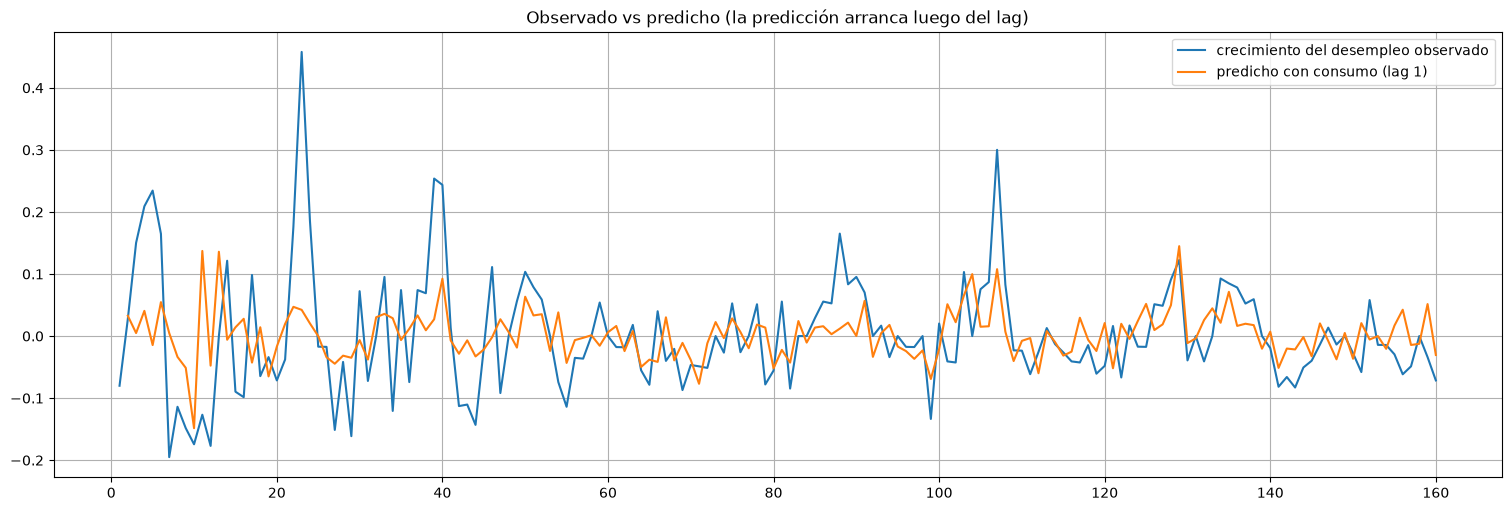

In [19]:
ax = y.plot(label='crecimiento del desempleo observado')
fit_lag.fittedvalues.plot(ax=ax, label=f'predicho con consumo (lag {l_opt})')
ax.legend()
ax.set_title('Observado vs predicho (la predicción arranca luego del lag)');

### 3.6 Residuos

     lb_stat  lb_pvalue
8  26.898103   0.000736


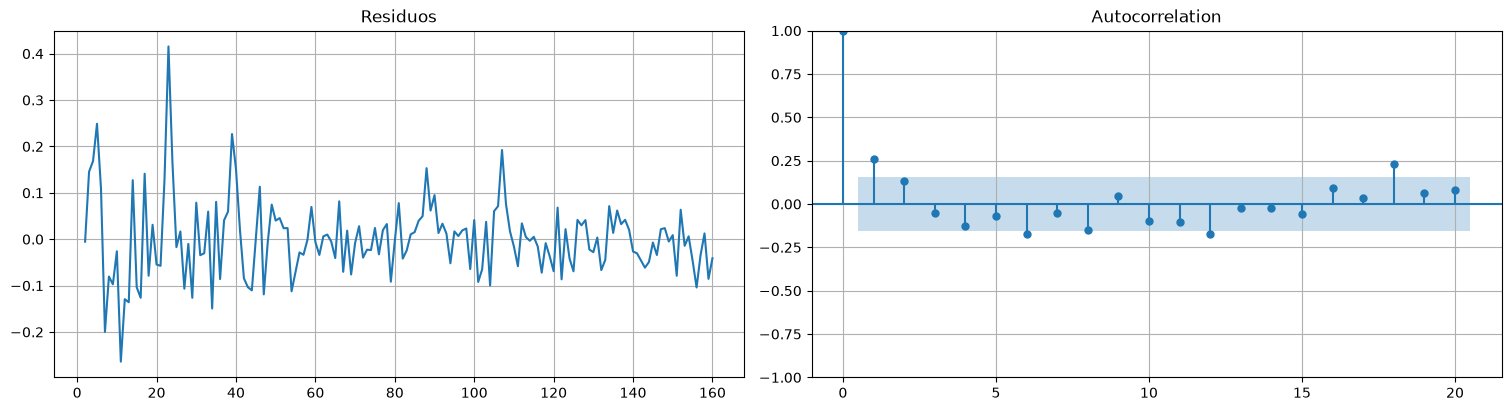

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fit_lag.resid.plot(ax=axs[0], title='Residuos')
plot_acf(fit_lag.resid, lags=20, bartlett_confint=False, ax=axs[1])
print(sm.stats.acorr_ljungbox(fit_lag.resid, lags=[8]))

**💬 Discusión 3.6** — β₁ es negativo y significativo: consumo y desempleo se mueven en sentido contrario. El R² deja la mayor parte de la varianza sin explicar. Mirar la ACF de los residuos: si queda correlación (aunque sea moderada), decir que **queda información por ajustar** — más lags de x, otros indicadores macro, o un ARMA para los residuos.

---
## Moraleja del parcial 2025 (y del patrón general)

El parcial 2025 es la **plantilla pura A-B-C**: idéntico en estructura a 2022, con otros datasets. Si el 2026 repite el molde: Ej. 1 = §A del toolkit, Ej. 2 = §B, Ej. 3 = §C. Si innova, lo más probable es que sea hacia espacio de estados (Ej. 3-2024, §D) — el docente actualizó DLM para 2026.